<h3><a href="https://themlpath.com">< The ML Path</a></h3>

<h1>Neural Networks</h1>

# Simple Perceptron

## What is a Perceptron?
A perceptron is a single-layer neural network designed for binary classification. It calculates a weighted sum of inputs, adds a bias, and applies an activation function to produce an output.

### Mathematical Model:
**y = f(w · x + b)**  
- **x**: Input vector (features).  
- **w**: Weights (one for each input).  
- **b**: Bias (scalar).  
- **f**: Activation function (e.g., step function).  
- **y**: Output (0 or 1 for binary classification).  

---

## Manually Calculate Outputs

Let’s classify points using a perceptron for the **Logical AND Gate**.

### Dataset:
```
X = [[0, 0],  
     [0, 1],  
     [1, 0],  
     [1, 1]]  
y = [0, 0, 0, 1]
```

### Initial Parameters:
- **Weights**: `w = [0.5, 0.5]`  
- **Bias**: `b = -0.7`  
- **Activation Function**: Step Function  
  ```
  f(x) = 1 if x >= 0 else 0
  ```

---

### Calculation for Each Input:
1. **For X = [0, 0]:**  
   ```
   z = w · x + b = (0.5 * 0 + 0.5 * 0) - 0.7 = -0.7  
   f(z) = 0
   ```

2. **For X = [1, 1]:**  
   ```
   z = w · x + b = (0.5 * 1 + 0.5 * 1) - 0.7 = 0.3  
   f(z) = 1
   ```

---

## Code a Perceptron (Without Training)

Let’s implement this manually in Python:
```python
import numpy as np

# Step Function as Activation
def step_function(x):
    return 1 if x >= 0 else 0

# Perceptron Model (Forward Pass Only)
class Perceptron:
    def __init__(self, weights, bias):
        self.weights = np.array(weights)
        self.bias = bias

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return step_function(z)

# Define Weights, Bias, and Dataset
weights = [0.5, 0.5]
bias = -0.7
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = [0, 0, 0, 1]  # AND Gate

# Initialize Perceptron and Make Predictions
perceptron = Perceptron(weights, bias)
for xi, yi in zip(X, y):
    prediction = perceptron.predict(xi)
    print(f"Input: {xi}, Predicted: {prediction}, Actual: {yi}")
```

**Expected Output**:
```
Input: [0 0], Predicted: 0, Actual: 0
Input: [0 1], Predicted: 0, Actual: 0
Input: [1 0], Predicted: 0, Actual: 0
Input: [1 1], Predicted: 1, Actual: 1
```


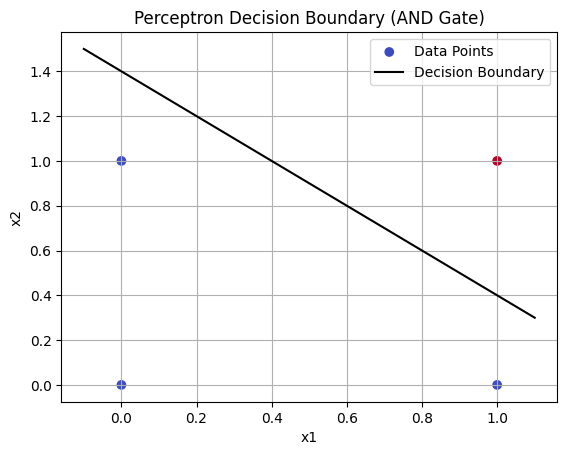

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Define Dataset (AND Gate)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 0, 0, 1])

# Define Weights and Bias
w = np.array([0.5, 0.5])
b = -0.7

# Define Decision Boundary
x_values = np.linspace(-0.1, 1.1, 100)
y_values = -(w[0] * x_values + b) / w[1]

# Plot Points
plt.scatter(X[:, 0], X[:, 1], c=y, cmap="coolwarm", label="Data Points")
plt.plot(x_values, y_values, label="Decision Boundary", color="black")

# Configure Plot
plt.title("Perceptron Decision Boundary (AND Gate)")
plt.xlabel("x1")
plt.ylabel("x2")
plt.legend()
plt.grid(True)
plt.show()


### Role of Bias:

- Without the bias, the decision boundary would always pass through the origin (0,0).
- The bias shifts the decision boundary, allowing the perceptron to classify data more flexibly.

# Activation Functions


The perceptron with a step function can only handle linearly separable problems. To solve more complex tasks, we need **non-linear activation functions** to introduce flexibility into the decision boundaries.

---

## Common Activation Functions

Here are the most commonly used activation functions:

1. **Step Function**:
   ```
   f(z) = 1 if z >= 0, else 0
   ```
   - Used in perceptrons.
   - Limitation: Cannot handle non-linear separability.

2. **Sigmoid Function**:
   ```
   f(z) = 1 / (1 + exp(-z))
   ```
   - Output: (0, 1).
   - Smooth gradient makes it suitable for backpropagation.

3. **ReLU (Rectified Linear Unit)**:
   ```
   f(z) = max(0, z)
   ```
   - Introduces sparsity by zeroing out negative values.
   - Common in deep learning models.

4. **Tanh (Hyperbolic Tangent)**:
   ```
   f(z) = (exp(z) - exp(-z)) / (exp(z) + exp(-z))
   ```
   - Output: (-1, 1).
   - Zero-centered, often preferred over sigmoid.

---

##  Update Perceptron to Support Multiple Activations

We’ll modify the perceptron to allow different activation functions.

```python
import numpy as np

# Activation Functions
def step_function(x):
    return 1 if x >= 0 else 0

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Perceptron Model with Activations
class Perceptron:
    def __init__(self, weights, bias, activation=step_function):
        self.weights = np.array(weights)
        self.bias = bias
        self.activation = activation

    def predict(self, x):
        z = np.dot(self.weights, x) + self.bias
        return self.activation(z)

# Define Weights, Bias, and Dataset
weights = [0.5, 0.5]
bias = -0.7
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])

# Use Sigmoid Activation
print("Using Sigmoid Activation:")
perceptron_sigmoid = Perceptron(weights, bias, activation=sigmoid)
for xi in X:
    print(f"Input: {xi}, Predicted: {perceptron_sigmoid.predict(xi):.4f}")

# Use ReLU Activation
print("\nUsing ReLU Activation:")
perceptron_relu = Perceptron(weights, bias, activation=relu)
for xi in X:
    print(f"Input: {xi}, Predicted: {perceptron_relu.predict(xi):.4f}")

# Use Tanh Activation
print("\nUsing Tanh Activation:")
perceptron_tanh = Perceptron(weights, bias, activation=tanh)
for xi in X:
    print(f"Input: {xi}, Predicted: {perceptron_tanh.predict(xi):.4f}")
```



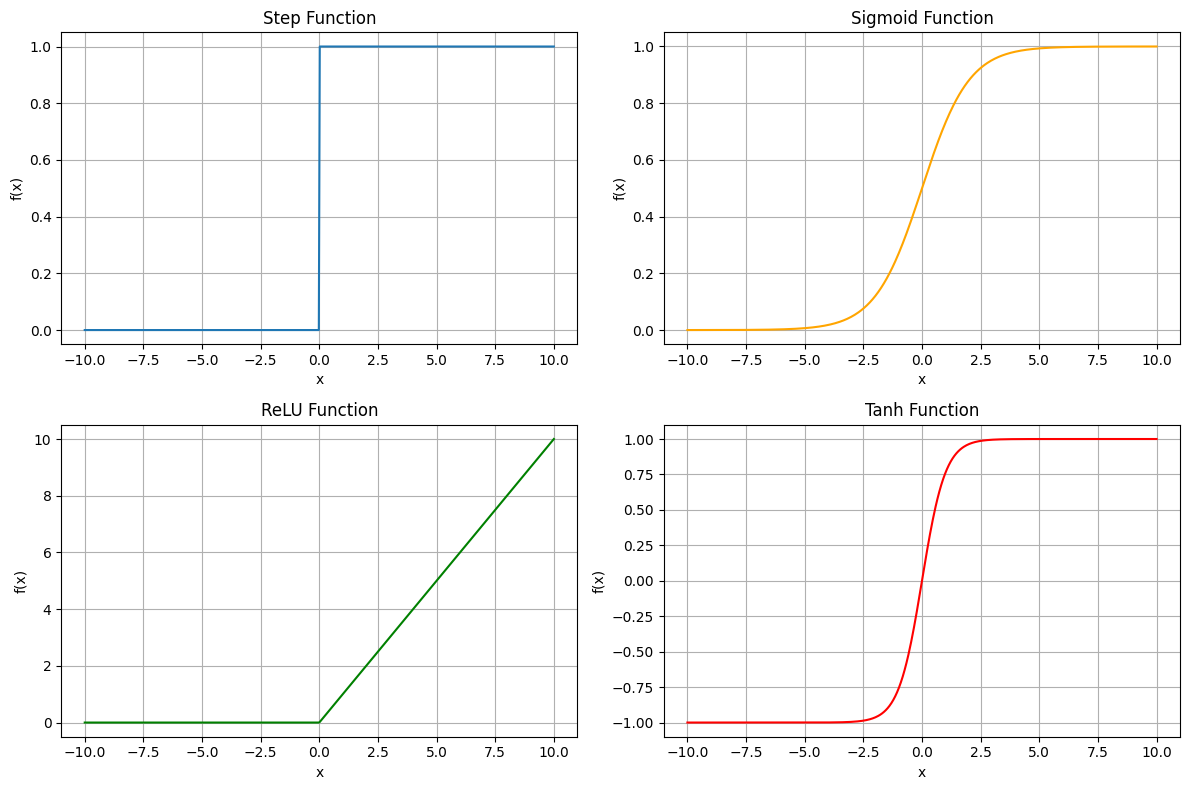

In [2]:
# Visualization of Common Activation Functions
import numpy as np
import matplotlib.pyplot as plt

# Define Activation Functions
def step_function(x):
    return np.where(x >= 0, 1, 0)

def sigmoid(x):
    return 1 / (1 + np.exp(-x))

def relu(x):
    return np.maximum(0, x)

def tanh(x):
    return np.tanh(x)

# Define Range of Input Values
x = np.linspace(-10, 10, 500)

# Compute Outputs for Each Activation Function
y_step = step_function(x)
y_sigmoid = sigmoid(x)
y_relu = relu(x)
y_tanh = tanh(x)

# Plot Activation Functions
plt.figure(figsize=(12, 8))

# Step Function
plt.subplot(2, 2, 1)
plt.plot(x, y_step, label="Step Function")
plt.title("Step Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# Sigmoid Function
plt.subplot(2, 2, 2)
plt.plot(x, y_sigmoid, label="Sigmoid", color="orange")
plt.title("Sigmoid Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# ReLU Function
plt.subplot(2, 2, 3)
plt.plot(x, y_relu, label="ReLU", color="green")
plt.title("ReLU Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# Tanh Function
plt.subplot(2, 2, 4)
plt.plot(x, y_tanh, label="Tanh", color="red")
plt.title("Tanh Function")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True)

# Adjust Layout and Show Plot
plt.tight_layout()
plt.show()
